# EDA

In [88]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score , accuracy_score

In [53]:
# Data Load

df = pd.read_csv(r"../dataset/train.csv")

df

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699630,699630,57,612,2,1,1,1,1,3,3,...,2,2,4,0,0.0,Female,Loyal Customer,Business travel,Eco,False
699631,699631,30,862,2,2,2,3,4,2,4,...,4,2,4,24,34.0,Female,disloyal Customer,Business travel,Eco,False
699632,699632,49,3148,5,5,5,5,4,4,4,...,5,5,5,0,0.0,Male,Loyal Customer,Business travel,Business,True
699633,699633,61,679,5,2,2,2,5,4,4,...,5,5,1,0,0.0,Female,Loyal Customer,Business travel,Eco,True


In [45]:
# Stats

df.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,699635.00000,699635.000000,699635.000000,699635.000000,699635.00000,699635.00000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699343.000000
mean,349817.00000,39.001928,1353.778702,2.778722,3.15621,2.81324,3.013734,3.265644,3.364156,3.568950,3.453910,3.517404,3.472847,3.805443,3.420291,3.380401,1.176209,1.134280
std,201967.37213,13.800943,954.422566,1.280419,1.47539,1.32955,1.254014,1.300202,1.288538,1.275333,1.308157,1.238474,1.271755,1.079175,1.210604,1.277870,5.982187,5.749304
min,0.00000,7.000000,67.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,174908.50000,27.000000,631.000000,2.000000,2.00000,2.00000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,349817.00000,40.000000,954.000000,3.000000,3.00000,3.00000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000,0.000000
75%,524725.50000,50.000000,1814.000000,4.000000,4.00000,4.00000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,0.000000,0.000000
max,699634.00000,85.000000,4983.000000,5.000000,5.00000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,489.000000,491.000000


In [54]:
# Null Values

print(df.isnull().sum())

id                                     0
Age                                    0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             292
Gender                                 0
Customer Type                          0
Type of Travel                         0
Class                                  0
satisfaction                           0
dtype: int64


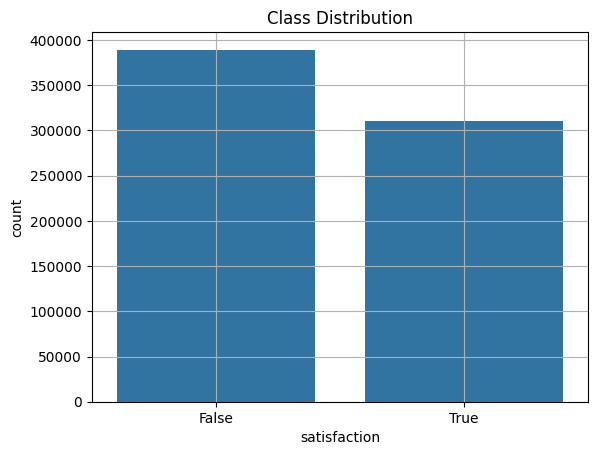

In [8]:
# Class Distribution

sns.countplot(
    x = "satisfaction" ,
    data = df
)
plt.title("Class Distribution")
plt.grid()
plt.show()

# The unsatisfaction ratio is more than the satisfaction ratio which is 
# (389296 : 310339) , means 55.64% values are false
# So the dataset is almost balanced

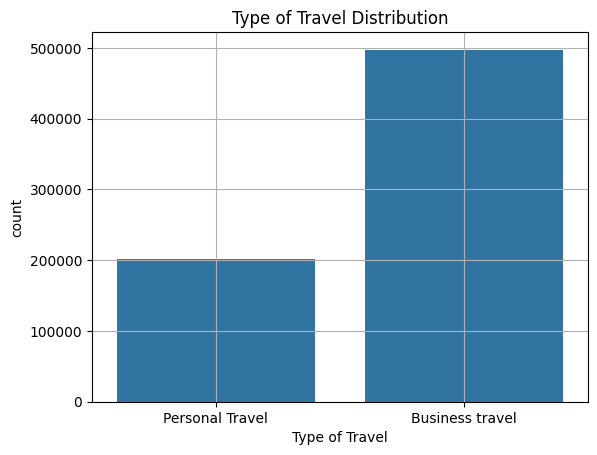

In [27]:
# Type of Travel Distribution

sns.countplot(
    x = "Type of Travel" ,
    data = df
)
plt.title("Type of Travel Distribution")
plt.grid()
plt.show()

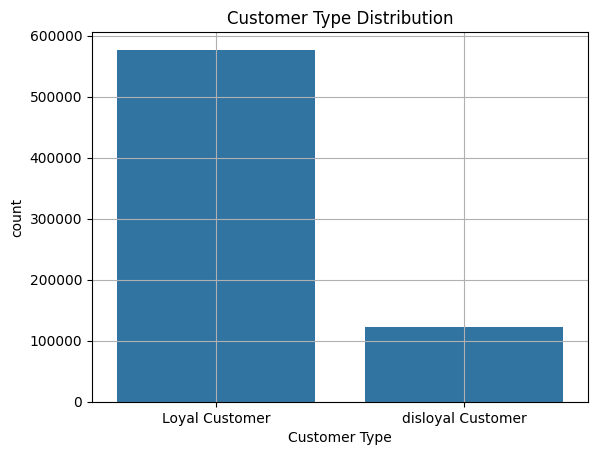

In [26]:
# Customer Type Distribution

sns.countplot(
    x = "Customer Type" ,
    data = df
)
plt.title("Customer Type Distribution")
plt.grid()
plt.show()

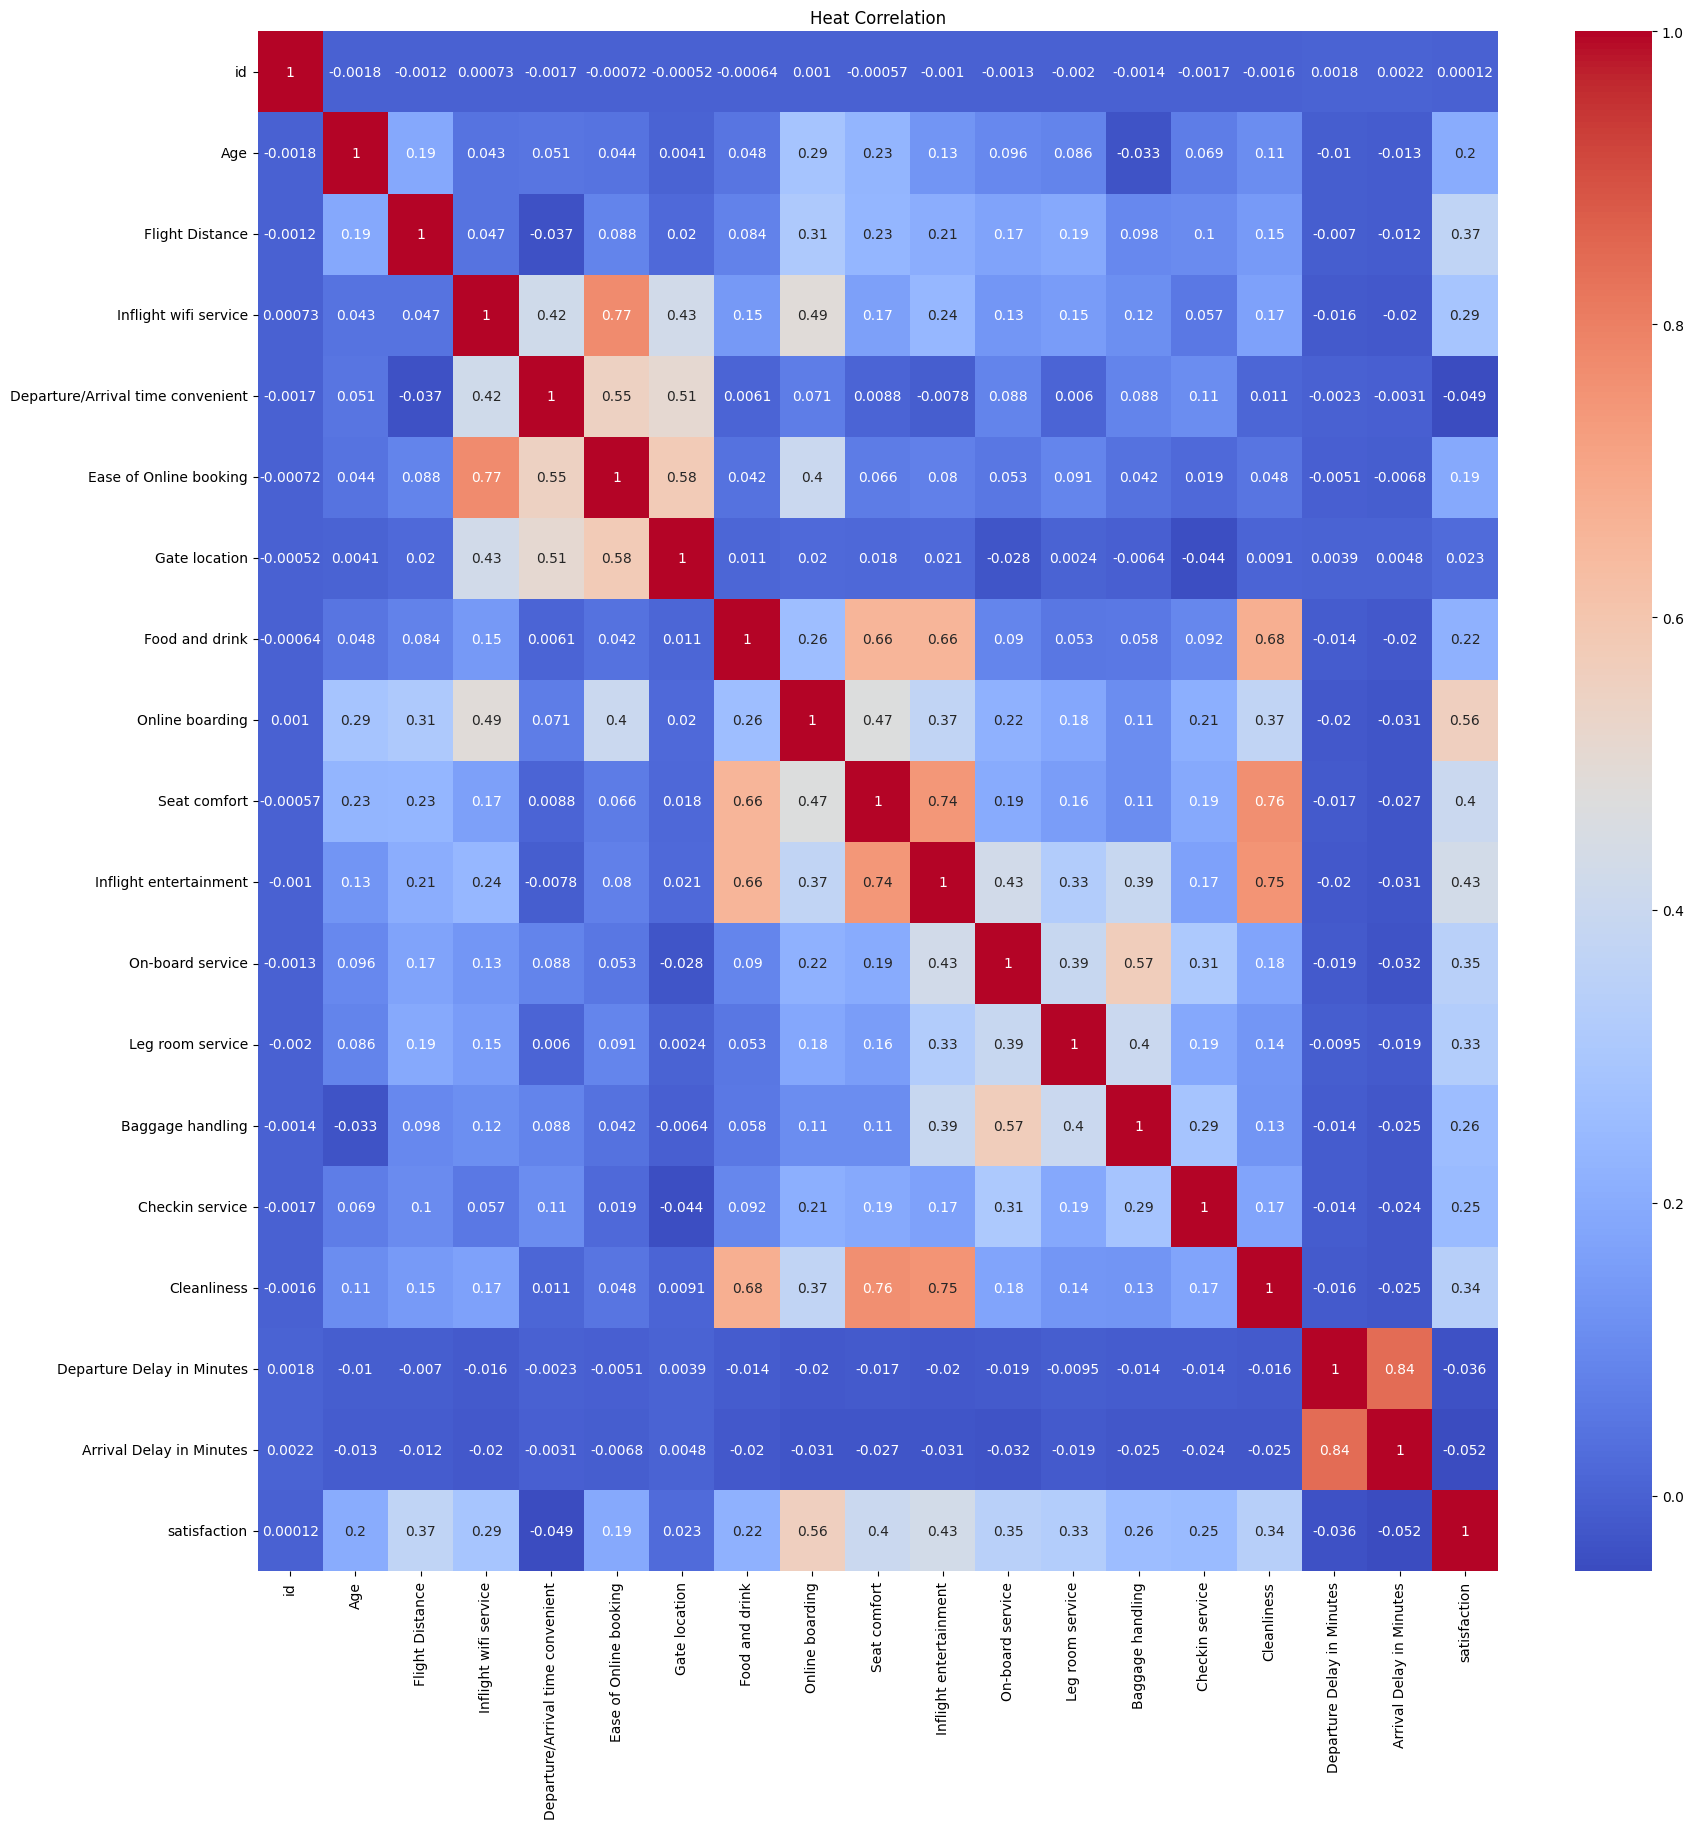

In [39]:
# Heat Map

plt.figure(figsize = (20 , 20))

sns.heatmap(
    df.corr(numeric_only = True) ,
    annot = True , 
    cmap = "coolwarm"
)

plt.title("Heat Correlation")
plt.show()

In [55]:
# Filling Null Values

ranges = [0 , 10 , 20 , 30 , 40 , 50 , 60 , 70 , 80 , 90 , 100 , 200 , 300 , 400 , 500]

j = 1 

for i in range(len(ranges) - 1):

    condition1 = (
    (df["Departure Delay in Minutes"] > ranges[i]) & 
    (df["Departure Delay in Minutes"] <= ranges[j]) & 
    (df["Arrival Delay in Minutes"].isnull())
    )
    
    condition2 = (
    (df["Departure Delay in Minutes"] > ranges[i]) & 
    (df["Departure Delay in Minutes"] <= ranges[j])
    )
    
    col = "Arrival Delay in Minutes"

    fill = float((df["Departure Delay in Minutes"][condition2]).mean())

    fill = round(fill , 2)
    
    df.loc[condition1 , col] = fill
    
    j = j + 1

df["Arrival Delay in Minutes"] = 0 

In [58]:
# Null Values 

print(df.isnull().sum())

id                                   0
Age                                  0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
Gender                               0
Customer Type                        0
Type of Travel                       0
Class                                0
satisfaction                         0
dtype: int64


In [124]:
# Data Prep

X = df.drop(["satisfaction"] , axis = 1)
y = df[["satisfaction"]]

y = OrdinalEncoder().fit_transform(y)
y = (pd.Series(y.flatten())).astype(int)

cat_cols = X.select_dtypes(include = ["string" , "object"]).columns
num_cols = X.select_dtypes(include = ["number"]).columns

X_train , X_test , y_train , y_test = train_test_split(
    X , 
    y , 
    test_size = 0.2 ,
    random_state = 42 ,
    stratify = y
)

In [99]:
# Base Model

preprocess = ColumnTransformer([
    ("cat" , OneHotEncoder(handle_unknown = "ignore") , cat_cols)
] , remainder = "passthrough")

model = Pipeline([
    ("preprocess" , preprocess) ,
    ("rf" , RandomForestClassifier())
])

model.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spars

In [105]:
# Scores

y_pred = model.predict(X_test)

f1 = f1_score(
    y_test ,
    y_pred
)
acc = accuracy_score(
    y_test ,
    y_pred
)


print(f"F1 SCORE : {f1}")
print(f"ACCURACY : {acc}")

F1 SCORE : 0.9134761507917055
ACCURACY : 0.924317679933108


In [125]:
# Feature Importance

rf = model.named_steps["rf"]
imp = rf.feature_importances_

imp = pd.Series(imp , index = model.named_steps["preprocess"].get_feature_names_out()).sort_values(ascending = False)

imp

remainder__Online boarding                      0.188167
remainder__Inflight wifi service                0.089413
cat__Class_Business                             0.078492
remainder__Flight Distance                      0.065006
remainder__Inflight entertainment               0.059276
remainder__Seat comfort                         0.051690
remainder__id                                   0.049092
cat__Type of Travel_Business travel             0.046905
remainder__Age                                  0.042846
cat__Type of Travel_Personal Travel             0.036455
cat__Class_Eco                                  0.036313
remainder__Checkin service                      0.027407
remainder__Leg room service                     0.027028
remainder__Ease of Online booking               0.026790
remainder__Cleanliness                          0.026672
remainder__On-board service                     0.026147
remainder__Baggage handling                     0.023760
cat__Customer Type_disloyal Cus